#### Imports

In [1]:
import os
from pathlib import Path
from typing import List, Dict, Any

import numpy as np
# import matplotlib.pyplot as plt
# from matplotlib import colormaps

from langchain_core.prompts import ChatPromptTemplate, MessagesPlaceholder
from langchain_classic.agents import create_tool_calling_agent
from langchain_classic.agents import AgentExecutor

from langchain_openai import ChatOpenAI

from PIL import Image
import cv2

os.environ['DISABLE_MODEL_SOURCE_CHECK'] = 'True'
from paddleocr import PaddleOCR

c:\Users\Ons\Desktop\projects\LemonADE\.venv\Lib\site-packages\requests\__init__.py:113: RequestsDependencyWarning: urllib3 (2.6.3) or chardet (6.0.0dev0)/charset_normalizer (3.4.4) doesn't match a supported version!
  warnings.warn(
c:\Users\Ons\Desktop\projects\LemonADE\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Checking connectivity to the model hosters, this may take a while. To bypass this check, set `PADDLE_PDX_DISABLE_MODEL_SOURCE_CHECK` to `True`.


### 1. PaddleOCR text extraction

In [2]:
from paddleocr import PaddleOCR
# Initialize once per kernel to avoid PDX reinit errors
if "ocr" not in globals():
    ocr = PaddleOCR(lang="en", enable_mkldnn=False,  # prevents MKLDNN/PIR crash
                    )

c:\Users\Ons\Desktop\projects\LemonADE\.venv\Lib\site-packages\paddle\utils\cpp_extension\extension_utils.py:712: UserWarning: No ccache found. Please be aware that recompiling all source files may be required. You can download and install ccache from: https://github.com/ccache/ccache/blob/master/doc/INSTALL.md
  warnings.warn(warning_message)
Creating model: ('PP-LCNet_x1_0_doc_ori', None)
Model files already exist. Using cached files. To redownload, please delete the directory manually: `C:\Users\Ons\.paddlex\official_models\PP-LCNet_x1_0_doc_ori`.
Creating model: ('UVDoc', None)
Model files already exist. Using cached files. To redownload, please delete the directory manually: `C:\Users\Ons\.paddlex\official_models\UVDoc`.
Creating model: ('PP-LCNet_x1_0_textline_ori', None)
Model files already exist. Using cached files. To redownload, please delete the directory manually: `C:\Users\Ons\.paddlex\official_models\PP-LCNet_x1_0_textline_ori`.
Creating model: ('PP-OCRv5_server_det', Non

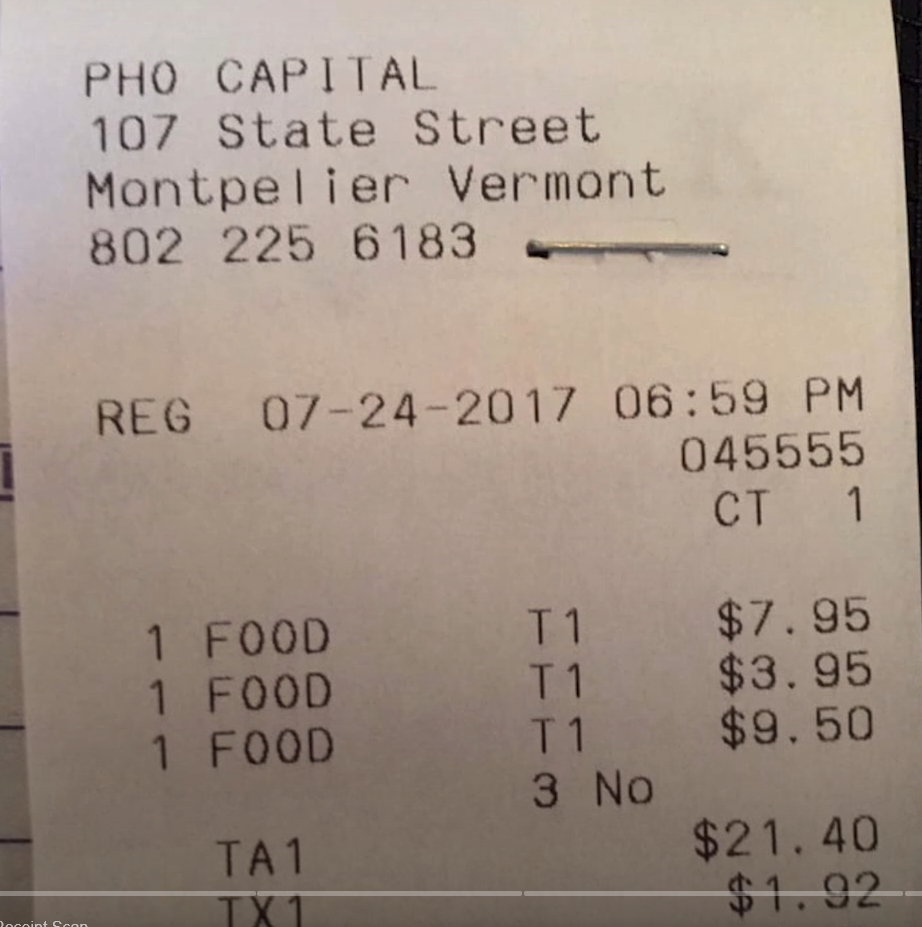

In [3]:
image_path = 'files/receipt_sample.png'
img = Image.open(image_path)
display(img)

In [4]:
# Run OCR
result = ocr.predict(image_path)

In [5]:
result

[{'input_path': 'files/receipt_sample.png',
  'page_index': None,
  'doc_preprocessor_res': {'input_path': None,
   'page_index': None,
   'input_img': array([[[192, ..., 194],
           ...,
           [ 25, ...,  26]],
   
          ...,
   
          [[ 58, ...,  74],
           ...,
           [ 72, ...,  90]]], shape=(927, 922, 3), dtype=uint8),
   'model_settings': {'use_doc_orientation_classify': True,
    'use_doc_unwarping': True},
   'angle': 0,
   'rot_img': array([[[192, ..., 194],
           ...,
           [ 25, ...,  26]],
   
          ...,
   
          [[ 58, ...,  74],
           ...,
           [ 72, ...,  90]]], shape=(927, 922, 3), dtype=uint8),
   'output_img': array([[[205, ..., 209],
           ...,
           [173, ..., 209]],
   
          ...,
   
          [[ 94, ..., 117],
           ...,
           [ 93, ..., 113]]], shape=(927, 922, 3), dtype=uint8)},
  'dt_polys': [array([[65,  1],
          ...,
          [66, 53]], shape=(4, 2), dtype=int16),
   arra

In [6]:
page = result[0]
texts = page['rec_texts'] # recognized text strings
scores = page['rec_scores'] # confidence scores for each text line
boxes  = page['rec_polys'] #  bounding box coordinates

for text, score, box in zip(texts, scores, boxes):
    # box is a numpy array like [[x1, y1], [x2, y2], [x3, y3], [x4, y4]]
    coords = box.astype(int).tolist()  # convert to normal list of ints
    print(f"{text:25} | {score:.3f} | {coords}")

PHO CAPITAL               | 0.973 | [[65, 1], [447, 0], [447, 51], [66, 53]]
107 State Street          | 0.996 | [[75, 59], [617, 64], [617, 122], [74, 117]]
Montpelier Vermont        | 0.999 | [[72, 125], [682, 130], [681, 187], [71, 182]]
802 225 6183              | 0.993 | [[75, 189], [506, 192], [505, 244], [74, 241]]
REG 07-24-2017 06:59 PM   | 0.994 | [[73, 374], [886, 358], [888, 419], [74, 435]]
045555                    | 1.000 | [[681, 428], [885, 423], [887, 475], [682, 480]]
CT 1                      | 0.923 | [[714, 481], [891, 477], [893, 538], [715, 542]]
T1                        | 0.987 | [[522, 609], [591, 609], [591, 664], [522, 664]]
$7.95                     | 0.999 | [[722, 601], [899, 596], [901, 657], [723, 662]]
1 FOOD                    | 0.906 | [[120, 620], [327, 614], [328, 671], [121, 677]]
T1                        | 0.944 | [[524, 669], [594, 669], [594, 722], [524, 722]]
$3.95                     | 0.999 | [[725, 660], [904, 655], [906, 715], [726, 720]

In [7]:
img = page['doc_preprocessor_res']['output_img']

[2026-02-24 21:39:54,456] [    INFO] font_manager.py:1639 - generated new fontManager


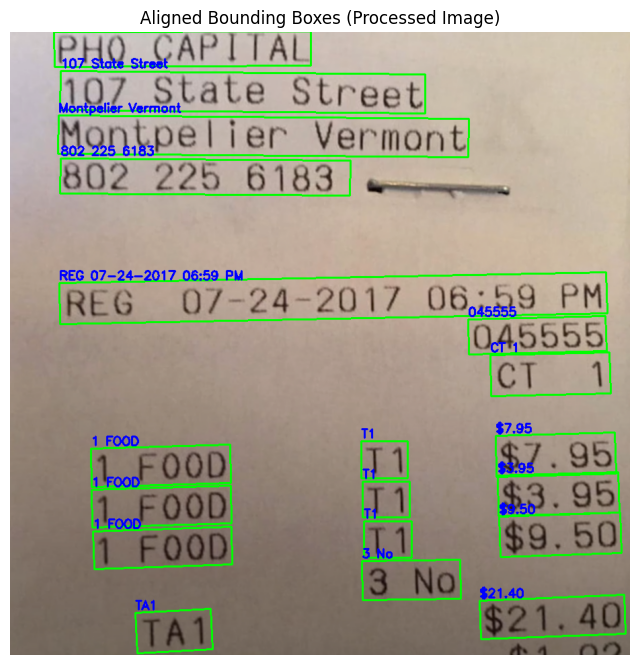

In [8]:
import matplotlib.pyplot as plt

img_plot = img.copy()

for text, box in zip(texts, boxes):
    pts = np.array(box, dtype=int)
    cv2.polylines(img_plot, [pts], True, (0, 255, 0), 2)
    x, y = pts[0]
    cv2.putText(img_plot, text, (x, y - 5), 
                cv2.FONT_HERSHEY_SIMPLEX, 0.6, (255, 0, 0), 2)

plt.figure(figsize=(8, 10))
plt.imshow(cv2.cvtColor(img_plot, cv2.COLOR_BGR2RGB))
plt.axis("off")
plt.title("Aligned Bounding Boxes (Processed Image)")
plt.show()

### 2. PaddleOCR Agentic tool

In [9]:
from langchain.tools import tool

@tool
def paddle_ocr_read_document(image_path: str) -> List[Dict[str, Any]]:
    """
    Reads an image from the given path and returns extracted text 
    with bounding boxes.
    
    Returns a list of dictionaries, each containing:
    - 'text': the recognized text string
    - 'bbox': bounding box coordinates [x_min, y_min, x_max, y_max]
    - 'confidence': recognition confidence score (if available)
    """
    try:
        result = ocr.predict(image_path)
        page = result[0]
        
        texts = page['rec_texts'] 
        boxes = page['dt_polys']         
        scores = page.get('rec_scores', [None] * len(texts))  
        
        extracted_items = []
        for text, box, score in zip(texts, boxes, scores):
            x_coords = [point[0] for point in box]
            y_coords = [point[1] for point in box]
            bbox = [min(x_coords), min(y_coords), max(x_coords), 
                    max(y_coords)]
            
            item = {
                'text': text,
                'bbox': bbox,
            }
            if score is not None:
                item['confidence'] = score
                
            extracted_items.append(item)
        
        return extracted_items
    
    except Exception as e:
        return [{"error": f"Error reading image: {e}"}]

In [10]:
# 1. Define the list of tools
tools = [paddle_ocr_read_document]

# 2. Set up the OpenAI GPT model
llm = ChatOpenAI(
    api_key=os.getenv("LMSTUDIO_API_KEY"),
    base_url=os.getenv("LMSTUDIO_BASE_URL"),
    model="google/gemma-3-27b", 
    temperature=1 
)

# 3. Create the OpenAI-compatible prompt
prompt = ChatPromptTemplate.from_messages([
    (
        "system",
        "You are a helpful assistant designed to extract information "+
        "from documents. "
            "You have access to this tool: "
            "Paddle OCR tool to extract raw texts, bounding boxes for "+
            "each text and confidence score from images "
        ),
        ("user", "{input}"),
        MessagesPlaceholder(variable_name="agent_scratchpad"),
    ]
)

# 4. Create a proper tool-calling agent
agent = create_tool_calling_agent(llm, tools, prompt)

# 5. Set up the AgentExecutor to run the tool-enabled loop
agent_executor = AgentExecutor(agent=agent, tools=tools, verbose=True)

In [11]:
task = """
Process the document at 'files/receipt_sample.png' and evaluate that 
the total is correct.
"""
response = agent_executor.invoke({"input": task})



> Entering new AgentExecutor chain...


[2026-02-24 22:57:27,512] [    INFO] _client.py:1025 - HTTP Request: POST http://localhost:1234/v1/chat/completions "HTTP/1.1 200 OK"



Invoking: `paddle_ocr_read_document` with `{'image_path': 'files/receipt_sample.png'}`
responded: Okay, I can help with that! I need to use the Paddle OCR tool to read the receipt image located at 'files/receipt_sample.png'. Once I have the extracted text and bounding boxes, I will attempt to identify the total amount on the receipt and verify its correctness.



[{'text': 'PHO CAPITAL', 'bbox': [np.int16(65), np.int16(0), np.int16(447), np.int16(53)], 'confidence': 0.9727867245674133}, {'text': '107 State Street', 'bbox': [np.int16(74), np.int16(59), np.int16(617), np.int16(122)], 'confidence': 0.9964346885681152}, {'text': 'Montpelier Vermont', 'bbox': [np.int16(71), np.int16(125), np.int16(682), np.int16(187)], 'confidence': 0.9987555742263794}, {'text': '802 225 6183', 'bbox': [np.int16(74), np.int16(189), np.int16(506), np.int16(244)], 'confidence': 0.9925954341888428}, {'text': 'REG 07-24-2017 06:59 PM', 'bbox': [np.int16(73), np.int16(358), np.int16(888), np.int16(435)], 'confi

[2026-02-24 22:59:07,695] [    INFO] _client.py:1025 - HTTP Request: POST http://localhost:1234/v1/chat/completions "HTTP/1.1 200 OK"


Okay, I've extracted the text from the receipt image. Now let's analyze it to find and verify the total amount.

From the extracted data, I can see these amounts:

*   $7.95
*   $3.95
*   $9.50
*   $21.40

Adding those up: $7.95 + $3.95 + $9.50 = $21.40

The final amount listed is also $21.40. Therefore, the total appears to be correct!

> Finished chain.
